In [58]:
# Project Scenario: Smart Waste Classification System
# A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

# Recyclable Waste

# Organic Waste

# Non-Recyclable Waste

# You are required to build a deep learning image classifier that can perform this task.



# TASK 1

# Show the dataset structure and total number of images in each class.

import os

base_dir = "dataset/train"

for category in os.listdir(base_dir):
    path = os.path.join(base_dir, category)
    print(category, ":", len(os.listdir(path)), "images")

non_recyclable : 89 images
organic : 327 images
recyclable : 990 images


In [9]:
import os

base_dir = "dataset/validation"

for category in os.listdir(base_dir):
    path = os.path.join(base_dir, category)
    print(category, ":", len(os.listdir(path)), "images")

non_recyclable : 79 images
organic : 195 images
recyclable : 530 images


In [10]:
# The code to show the structure ---I have tested it and alredy run but while showing output its getting very lengthy thatwhy
# i have made it in a comment section

# import os

# def print_structure(folder, indent=0):
#     for item in os.listdir(folder):
#         path = os.path.join(folder, item)
#         print("   " * indent + "|-- " + item)
        
#         if os.path.isdir(path):
#             print_structure(path, indent + 1)

# print("dataset")
# print_structure("dataset")

In [17]:
# Task 2 – Data Preprocessing

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    horizontal_flip=True,
    zoom_range=0.2,
    brightness_range=[0.8,1.2]
)

# Validation generator (no augmentation)
val_datagen = ImageDataGenerator(rescale=1./255)

# Load training dataset
train_data = train_datagen.flow_from_directory(
    "dataset/train",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Load validation dataset
val_data = val_datagen.flow_from_directory(
    "dataset/validation",
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

# Print outputs
print("Class Labels:", train_data.class_indices)
print("Training Samples:", train_data.samples)
print("Validation Samples:", val_data.samples)
print("Batch Size:", train_data.batch_size)
print("Image Shape:", train_data.image_shape)

Found 1406 images belonging to 3 classes.
Found 804 images belonging to 3 classes.
Class Labels: {'non_recyclable': 0, 'organic': 1, 'recyclable': 2}
Training Samples: 1406
Validation Samples: 804
Batch Size: 32
Image Shape: (224, 224, 3)


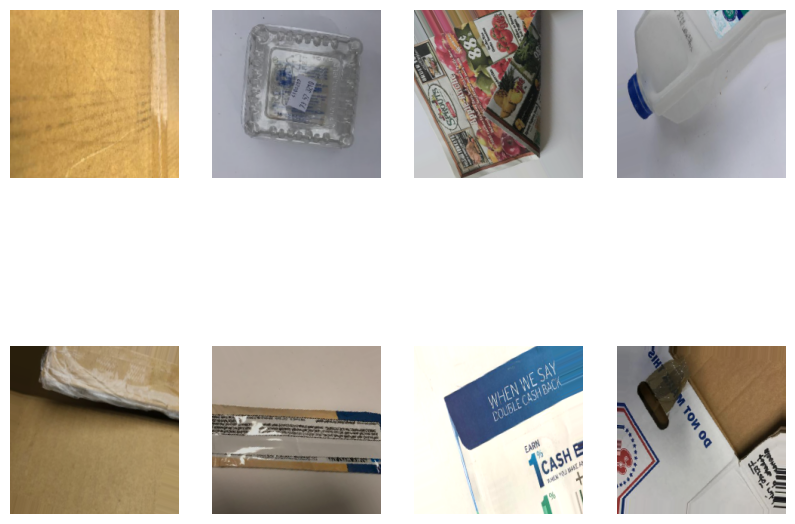

In [26]:
# prints my augmented results

import matplotlib.pyplot as plt

images, labels = next(train_data)

plt.figure(figsize=(10,8))

for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [27]:
# Task 3 -- CNN Model Development

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(3,activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\naina\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 132s 3s/step - accuracy: 0.6799 - loss: 1.0115 - val_accuracy: 0.6592 - val_loss: 0.9091
Epoch 2/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.7041 - loss: 0.7630 - val_accuracy: 0.6592 - val_loss: 0.7917
Epoch 3/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.7006 - loss: 0.7398 - val_accuracy: 0.7127 - val_loss: 0.7382
Epoch 4/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 173s 4s/step - accuracy: 0.7098 - loss: 0.6622 - val_accuracy: 0.7177 - val_loss: 0.7414
Epoch 5/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 166s 4s/step - accuracy: 0.7333 - loss: 0.5945 - val_accuracy: 0.7040 - val_loss: 0.6814
Epoch 6/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 165s 4s/step - accuracy: 0.7461 - loss: 0.5670 - val_accuracy: 0.7276 - val_loss: 0.6061
Epoch 7/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 154s 4s/step - accuracy: 0.7568 - loss: 0.5028 - val_accuracy: 0.6940 - val_loss: 0.6586
Epoch 8/10
44/44 ━━━━━━━━━━━━━━━━━━━━ 157s 4s/step - accuracy: 0.7738 - loss: 0.5034 - val_accuracy: 0.6965 - val

In [30]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.7809388041496277
Final Validation Accuracy: 0.75


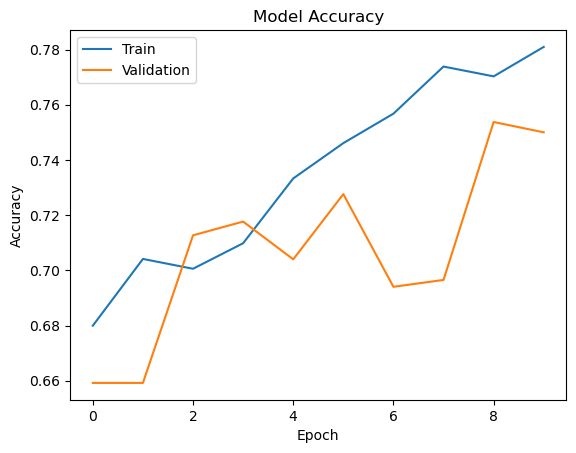

In [31]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

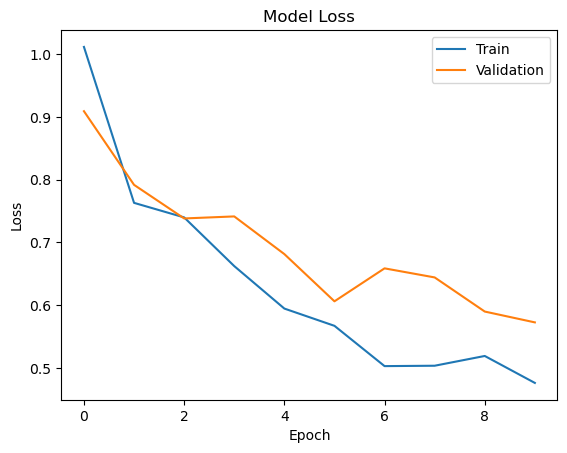

In [32]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.legend(["Train","Validation"])
plt.show()

In [33]:
# Task 4 – Model Evaluation

In [34]:
from sklearn.metrics import confusion_matrix
import numpy as np

pred = model.predict(val_data)
predicted_classes = np.argmax(pred, axis=1)

true_classes = val_data.classes

cm = confusion_matrix(true_classes, predicted_classes)
print(cm)

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 641ms/step
[[  0  22  57]
 [  8  60 127]
 [  3 147 380]]


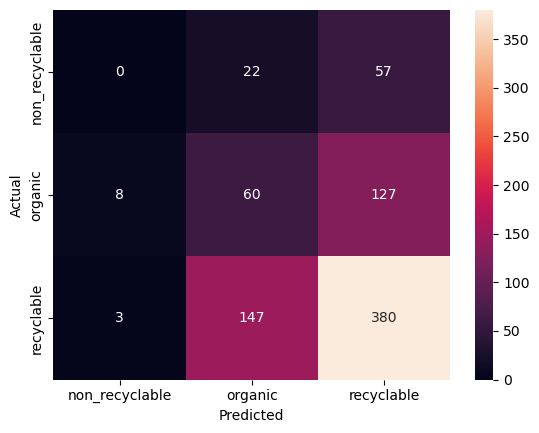

In [35]:
import seaborn as sns

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=train_data.class_indices,
            yticklabels=train_data.class_indices)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [51]:
from tensorflow.keras.preprocessing import image
import numpy as np

# img_path = "dataset/train/organic/paper76.jpg"
# img_path = "dataset/train/recyclable/metal76.jpg"
# img_path = "dataset/train/recyclable/cardboard76.jpg"
# img_path = "dataset/train/non_recyclable/trash2.jpg"
img_path = "dataset/train/recyclable/glass76.jpg"

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

classes = ['non_recyclable','organic','recyclable']
print("Predicted Class:", classes[np.argmax(prediction)])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
Predicted Class: recyclable


In [52]:
# Task 5 – Transfer Learning Implementation 

In [53]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

for layer in base_model.layers:
    layer.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


In [54]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

predictions = Dense(3, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=predictions)

transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

transfer_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,371 (90.98 MB)

 Trainable params: 262,659 (1.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [55]:
history_transfer = transfer_model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 326s 7s/step - accuracy: 0.6999 - loss: 0.7899 - val_accuracy: 0.6754 - val_loss: 0.8468
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 302s 7s/step - accuracy: 0.7248 - loss: 0.7391 - val_accuracy: 0.7065 - val_loss: 0.7803
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 294s 7s/step - accuracy: 0.7319 - loss: 0.7034 - val_accuracy: 0.7164 - val_loss: 0.7967
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 295s 7s/step - accuracy: 0.7354 - loss: 0.7169 - val_accuracy: 0.7152 - val_loss: 0.8020
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 323s 7s/step - accuracy: 0.7347 - loss: 0.7170 - val_accuracy: 0.7164 - val_loss: 0.7770


In [61]:
# Accuracy comparison between Custom CNN vs Transfer Learning model

# Final accuracy of Custom CNN
cnn_train_acc = history.history['accuracy'][-1]
cnn_val_acc = history.history['val_accuracy'][-1]

# Final accuracy of Transfer Learning model
transfer_train_acc = history_transfer.history['accuracy'][-1]
transfer_val_acc = history_transfer.history['val_accuracy'][-1]

print("Custom CNN Training Accuracy:", cnn_train_acc)
print("Custom CNN Validation Accuracy:", cnn_val_acc)

print("\nTransfer Learning Training Accuracy:", transfer_train_acc)
print("Transfer Learning Validation Accuracy:", transfer_val_acc)

Custom CNN Training Accuracy: 0.7809388041496277
Custom CNN Validation Accuracy: 0.75

Transfer Learning Training Accuracy: 0.7347083687782288
Transfer Learning Validation Accuracy: 0.7164179086685181


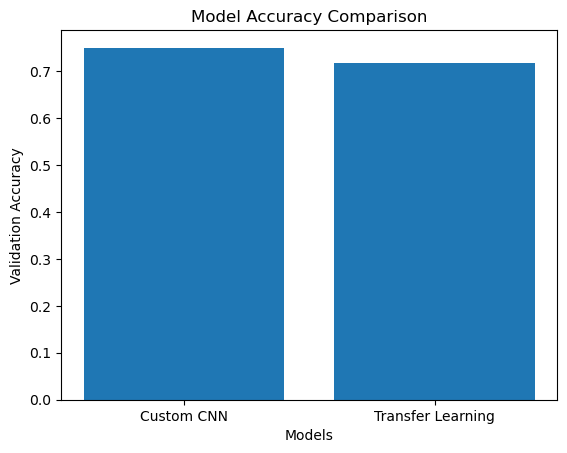

In [60]:
import matplotlib.pyplot as plt

models = ['Custom CNN','Transfer Learning']
accuracy = [cnn_val_acc, transfer_val_acc]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.xlabel("Models")

plt.show()